In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Watershed

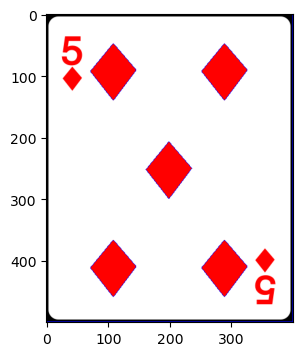

In [3]:
img = cv2.imread("img/5_of_diamonds.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

# Remove noise.
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Find the sure background region.
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Find the sure foreground region.
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)

# Find the unknown region.
unknown = cv2.subtract(sure_bg, sure_fg)

# Label the foreground objects.
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1.
markers += 1

# Label the unknown region as 0.
markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]  # ty:ignore[invalid-assignment]

_, ax = plt.subplots(figsize=(8, 4))

ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))